***Step 6***

*Import data*

In [1]:
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

import os
hour = int(os.environ['HOUR'])

from data import generators, generator_bid_prices, load_profile, load_distribution
from data import Prices_for_loads
import json


# ── Variable names ────────────────────────────────────────────────────
VARIABLES  = list(generators.keys())
conv_names = [v for v in VARIABLES if v.startswith('G')]
wind_names = [v for v in VARIABLES if v.startswith('W')]

# ── Raw data (hour 12) ────────────────────────────────────────────────
gen_costs    = {g: generator_bid_prices[g][12] for g in conv_names}   # marginal costs [$/MWh]
gen_max_caps = {g: generators[g]['Pmax_MW']    for g in conv_names}   # max capacities [MW]
hour_load  = load_profile[hour]                                    # total demand [MW]

print(f"Hour 12 load:  {hour_load:.2f} MW")
print(f"Gen costs:     {gen_costs}")
print(f"Gen maximum capacities:      {gen_max_caps}")

Hour 12 load:  2650.50 MW
Gen costs:     {'G1': 11.59, 'G2': 11.59, 'G3': 18.01, 'G4': 18.21, 'G5': 22.72, 'G6': 9.15, 'G7': 9.15, 'G8': 5.24, 'G9': 4.76, 'G10': 0, 'G11': 9.15, 'G12': 9.47}
Gen maximum capacities:      {'G1': 152, 'G2': 152, 'G3': 350, 'G4': 591, 'G5': 60, 'G6': 155, 'G7': 155, 'G8': 400, 'G9': 400, 'G10': 300, 'G11': 310, 'G12': 350}


In [2]:

# Absolute path to data_from_Jakob — works regardless of how notebook is run
DATA_DIR = r'C:\Users\inesm\Desktop\DTU\Spring 2026\RIEM\RIEM project\46755-Group03\data_from_Jakob'

W1_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone1.csv'))
W1_CF   = W1_data.iloc[1:25, 1:].mean(axis=1)

W2_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone2.csv'))
W2_CF   = W2_data.iloc[1:25, 1:].mean(axis=1)

W3_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone3.csv'))
W3_CF   = W3_data.iloc[1:25, 1:].mean(axis=1)

W4_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone4.csv'))
W4_CF   = W4_data.iloc[1:25, 1:].mean(axis=1)

W5_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone5.csv'))
W5_CF   = W5_data.iloc[1:25, 1:].mean(axis=1)

W6_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone6.csv'))
W6_CF   = W6_data.iloc[1:25, 1:].mean(axis=1)

**Reserve requirements**

In [3]:
R_up_req   = 0.15 * hour_load   # upward reserve requirement
R_down_req = 0.10 * hour_load   # downward reserve requirement

print(f"Upward reserve requirement:   {R_up_req:.2f} MW  (15% of {hour_load:.2f} MW)")
print(f"Downward reserve requirement: {R_down_req:.2f} MW  (10% of {hour_load:.2f} MW)")

Upward reserve requirement:   397.57 MW  (15% of 2650.50 MW)
Downward reserve requirement: 265.05 MW  (10% of 2650.50 MW)


**European style: reserve market first, then DA**

In [4]:
RESERVE_SUBSET = {'G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10', 'G11'}   # same subset as Step 5

reserve_up_offers   = {}   # {generator: (offer_price EUR/MWh, max_MW)}
reserve_down_offers = {}   # {generator: (offer_price EUR/MWh, max_MW)}

for g in conv_names:
    if g not in RESERVE_SUBSET:
        continue

    c_i     = gen_costs[g]        # marginal cost of generator g [EUR/MWh]
    g_max_i = gen_max_caps[g]     # maximum capacity of generator g [MW] #are we sure we want to use the max capacity here? maybe we should use only a %
    # Each generator bids its full capacity for both directions
    # Offer price = fraction of marginal cost (opportunity cost of reserving capacity)
    reserve_up_offers[g]   = (0.20 * c_i, 0.3*g_max_i)   # upward:   20% of marginal cost
    reserve_down_offers[g] = (0.15 * c_i, 0.3*g_max_i)   # downward: 15% of marginal cost

print("Reserve upward offers (price = 20% of marginal cost, max = full capacity):")
for g, (p, mw) in reserve_up_offers.items():
    print(f"  {g}: {p:.2f} EUR/MWh   max {mw:.2f} MW  (C_g = {gen_costs[g]:.2f} EUR/MWh)")

print("\nReserve downward offers (price = 15% of marginal cost, max = full capacity):")
for g, (p, mw) in reserve_down_offers.items():
    print(f"  {g}: {p:.2f} EUR/MWh   max {mw:.2f} MW  (C_g = {gen_costs[g]:.2f} EUR/MWh)")

Reserve upward offers (price = 20% of marginal cost, max = full capacity):
  G1: 2.32 EUR/MWh   max 45.60 MW  (C_g = 11.59 EUR/MWh)
  G2: 2.32 EUR/MWh   max 45.60 MW  (C_g = 11.59 EUR/MWh)
  G3: 3.60 EUR/MWh   max 105.00 MW  (C_g = 18.01 EUR/MWh)
  G4: 3.64 EUR/MWh   max 177.30 MW  (C_g = 18.21 EUR/MWh)
  G5: 4.54 EUR/MWh   max 18.00 MW  (C_g = 22.72 EUR/MWh)
  G6: 1.83 EUR/MWh   max 46.50 MW  (C_g = 9.15 EUR/MWh)
  G7: 1.83 EUR/MWh   max 46.50 MW  (C_g = 9.15 EUR/MWh)
  G8: 1.05 EUR/MWh   max 120.00 MW  (C_g = 5.24 EUR/MWh)
  G9: 0.95 EUR/MWh   max 120.00 MW  (C_g = 4.76 EUR/MWh)
  G10: 0.00 EUR/MWh   max 90.00 MW  (C_g = 0.00 EUR/MWh)
  G11: 1.83 EUR/MWh   max 93.00 MW  (C_g = 9.15 EUR/MWh)

Reserve downward offers (price = 15% of marginal cost, max = full capacity):
  G1: 1.74 EUR/MWh   max 45.60 MW  (C_g = 11.59 EUR/MWh)
  G2: 1.74 EUR/MWh   max 45.60 MW  (C_g = 11.59 EUR/MWh)
  G3: 2.70 EUR/MWh   max 105.00 MW  (C_g = 18.01 EUR/MWh)
  G4: 2.73 EUR/MWh   max 177.30 MW  (C_g = 18.21

***Solve European Model***

In [5]:
model_R = gp.Model("ReserveMarket_European")
model_R.Params.OutputFlag = 0
model_R.Params.InfUnbdInfo = 1

# Reserve capacity variables
r_up   = {g: model_R.addVar(lb=0, ub=reserve_up_offers[g][1],   name=f'rup_{g}')
          for g in reserve_up_offers}
r_down = {g: model_R.addVar(lb=0, ub=reserve_down_offers[g][1], name=f'rdn_{g}')
          for g in reserve_down_offers}

# Must meet reserve requirements
c_up   = model_R.addConstr(gp.quicksum(r_up[g]   for g in r_up)   >= R_up_req,   name="req_up")
c_down = model_R.addConstr(gp.quicksum(r_down[g] for g in r_down) >= R_down_req, name="req_down")

# (37) Combined up + down reserve cannot exceed generator max capacity
c_combined = {g: model_R.addConstr(
    r_up[g] + r_down[g] <= gen_max_caps[g], 
    name=f"combined_{g}")
    for g in r_up}

# Minimise total reserve procurement cost
obj_R = (gp.quicksum(reserve_up_offers[g][0]  * r_up[g]   for g in r_up) +
         gp.quicksum(reserve_down_offers[g][0] * r_down[g] for g in r_down))

model_R.setObjective(obj_R, GRB.MINIMIZE)

model_R.Params.DualReductions = 0
model_R.optimize()

# Reserve clearing prices (duals)
lambda_R_up   = c_up.Pi
lambda_R_down = c_down.Pi

print(f"Reserve up   clearing price: {lambda_R_up:.2f} $/MWh")
print(f"Reserve down clearing price: {lambda_R_down:.2f} $/MWh")
print(f"\nCommitted reserve capacity:")
for g in r_up:
    up_val   = r_up[g].X
    down_val = r_down[g].X if g in r_down else 0.0
    print(f"  {g}: up={up_val:.2f} MW  |  down={down_val:.2f} MW")

# Committed reserve per generator
reserved_up   = {g: r_up[g].X   for g in r_up}
reserved_down = {g: r_down[g].X for g in r_down}


# --- Generator earnings (paid at clearing price) ---
print(f"\nGenerator earnings in reserve market:")
tso_total_payment = 0
for g in RESERVE_SUBSET:
    earn_up   = lambda_R_up   * reserved_up[g]
    earn_down = lambda_R_down * reserved_down[g]
    total_earn = earn_up + earn_down
    tso_total_payment += total_earn
    print(f"  {g}: up={earn_up:.2f} $  |  down={earn_down:.2f} $  |  total={total_earn:.2f} $")

print(f"\nTSO total reserve procurement cost: {tso_total_payment:.2f} $")

Set parameter Username


Set parameter LicenseID to value 2658987


Academic license - for non-commercial use only - expires 2026-04-29


Reserve up   clearing price: 1.83 $/MWh
Reserve down clearing price: 0.79 $/MWh

Committed reserve capacity:
  G1: up=0.00 MW  |  down=0.00 MW
  G2: up=0.00 MW  |  down=0.00 MW
  G3: up=0.00 MW  |  down=0.00 MW
  G4: up=0.00 MW  |  down=0.00 MW
  G5: up=0.00 MW  |  down=0.00 MW
  G6: up=46.50 MW  |  down=0.00 MW
  G7: up=21.07 MW  |  down=0.00 MW
  G8: up=120.00 MW  |  down=55.05 MW
  G9: up=120.00 MW  |  down=120.00 MW
  G10: up=90.00 MW  |  down=90.00 MW
  G11: up=0.00 MW  |  down=0.00 MW

Generator earnings in reserve market:
  G10: up=164.70 $  |  down=70.74 $  |  total=235.44 $
  G9: up=219.60 $  |  down=94.32 $  |  total=313.92 $
  G5: up=0.00 $  |  down=0.00 $  |  total=0.00 $
  G3: up=0.00 $  |  down=0.00 $  |  total=0.00 $
  G2: up=0.00 $  |  down=0.00 $  |  total=0.00 $
  G7: up=38.57 $  |  down=0.00 $  |  total=38.57 $
  G8: up=219.60 $  |  down=43.27 $  |  total=262.87 $
  G11: up=0.00 $  |  down=0.00 $  |  total=0.00 $
  G4: up=0.00 $  |  down=0.00 $  |  total=0.00 $
  G1:

***Solve DA market (European sequential)***

In [6]:
from data import load_distribution, load_profile, generators, generator_bid_prices
from data import Prices_for_loads

# --- Variable name lists ---
VARIABLES      = list(generators.keys())
LOAD_VARIABLES = list(load_distribution.keys())

# --- Generator costs ---
Generation_price = [v[hour] for v in generator_bid_prices.values()]
gen_costs        = {VARIABLES[i]: Generation_price[i] for i in range(len(VARIABLES))}

# --- Load setup ---
Load_percentage = [v['percent'] for v in load_distribution.values()]
DA_load         = hour_load
Load_DA         = [DA_load * (p / 100) for p in Load_percentage]

# --- Demand bid prices ---
Demand_price_DA      = np.array(sorted(Prices_for_loads[hour], reverse=True)) 
Load_coefficients_DA = {LOAD_VARIABLES[i]: Demand_price_DA[i] for i in range(len(LOAD_VARIABLES))}

# --- Generator capacity bounds ---
Generator_UB    = [v['Pmax_MW'] for k, v in generators.items() if k.startswith('G')]
Wind_UB         = np.array([W1_CF[hour], W2_CF[hour], W3_CF[hour],
                             W4_CF[hour], W5_CF[hour], W6_CF[hour]]) * 200
Constraints_rhs = Generator_UB + Wind_UB.tolist()

# Dict of max capacity per generator for headroom constraint
gen_max_caps = {VARIABLES[i]: Constraints_rhs[i] for i in range(len(VARIABLES))}

# --- Model ---
model_DA_eu = gp.Model("DA_European_AfterReserve")
model_DA_eu.Params.OutputFlag     = 0
model_DA_eu.Params.DualReductions = 0

# Generation variables
p_da = {}
for v, rhs in zip(VARIABLES, Constraints_rhs):
    p_da[v] = model_DA_eu.addVar(lb=0, ub=rhs, name=f'p_{v}')

# Load variables
p_load = {l: model_DA_eu.addVar(lb=0, ub=Load_DA[i], name=f'load_{l}')
          for i, l in enumerate(LOAD_VARIABLES)}

# --- Headroom: p_da[g] <= P_g_max - reserved_up[g] ---
c_headroom = {}
for g in reserved_up:
    c_headroom[g] = model_DA_eu.addConstr(
        p_da[g] <= gen_max_caps[g] - reserved_up[g],
        name=f"headroom_{g}"
    )

# --- Footroom: p_da[g] >= reserved_down[g] ---
c_footroom = {}
for g in reserved_down:
    c_footroom[g] = model_DA_eu.addConstr(
        p_da[g] >= reserved_down[g],
        name=f"footroom_{g}"
    )

# --- Demand balance ---
c_balance = model_DA_eu.addConstr(
    gp.quicksum(p_load[l] for l in p_load) - gp.quicksum(p_da[v] for v in p_da) == 0,
    name="balance"
)

# --- Maximise social welfare ---
obj_DA_eu = (gp.quicksum(Load_coefficients_DA[l] * p_load[l] for l in p_load) -
             gp.quicksum(gen_costs.get(g, 0) * p_da[g] for g in p_da))
model_DA_eu.setObjective(obj_DA_eu, GRB.MAXIMIZE)
model_DA_eu.optimize()

lambda_DA_eu = c_balance.Pi

# --- Results ---
print(f"DA clearing price (after reserve): {lambda_DA_eu:.2f} $/MWh")

# Producer surplus
print(f"\nProducer surplus per generator:")
total_prod_surplus = 0
for g in p_da:
    if p_da[g].X > 1e-3:
        surplus = (lambda_DA_eu - gen_costs.get(g, 0)) * p_da[g].X
        total_prod_surplus += surplus
        print(f"  {g}: {surplus:.2f} $  (dispatch={p_da[g].X:.2f} MW, cost={gen_costs.get(g,0):.2f} $/MWh)")

# Consumer surplus
print(f"\nConsumer surplus per load:")
total_cons_surplus = 0
for l in p_load:
    if p_load[l].X > 1e-3:
        surplus = (Load_coefficients_DA[l] - lambda_DA_eu) * p_load[l].X
        total_cons_surplus += surplus
        print(f"  {l}: {surplus:.2f} $  (consumption={p_load[l].X:.2f} MW, bid={Load_coefficients_DA[l]:.2f} $/MWh)")

# What each load pays
print(f"\nTotal payment per load:")
for l in p_load:
    if p_load[l].X > 1e-3:
        payment = lambda_DA_eu * p_load[l].X
        print(f"  {l}: {payment:.2f} $")

# Totals
social_welfare_eu = model_DA_eu.ObjVal
print(f"\nTotal producer surplus: {total_prod_surplus:.2f} $")
print(f"Total consumer surplus: {total_cons_surplus:.2f} $")
print(f"Social welfare (DA):    {social_welfare_eu:.2f} $")

DA clearing price (after reserve): 11.59 $/MWh

Producer surplus per generator:
  G1: 0.00 $  (dispatch=151.09 MW, cost=11.59 $/MWh)
  G6: 264.74 $  (dispatch=108.50 MW, cost=9.15 $/MWh)
  G7: 326.78 $  (dispatch=133.93 MW, cost=9.15 $/MWh)
  G8: 1778.00 $  (dispatch=280.00 MW, cost=5.24 $/MWh)
  G9: 1912.40 $  (dispatch=280.00 MW, cost=4.76 $/MWh)
  G10: 2433.90 $  (dispatch=210.00 MW, cost=0.00 $/MWh)
  G11: 756.40 $  (dispatch=310.00 MW, cost=9.15 $/MWh)
  G12: 742.00 $  (dispatch=350.00 MW, cost=9.47 $/MWh)
  W1: 1525.59 $  (dispatch=131.63 MW, cost=0.00 $/MWh)
  W2: 1660.66 $  (dispatch=143.28 MW, cost=0.00 $/MWh)
  W3: 1652.08 $  (dispatch=142.54 MW, cost=0.00 $/MWh)
  W4: 1445.01 $  (dispatch=124.68 MW, cost=0.00 $/MWh)
  W5: 1679.21 $  (dispatch=144.88 MW, cost=0.00 $/MWh)
  W6: 1622.25 $  (dispatch=139.97 MW, cost=0.00 $/MWh)

Consumer surplus per load:
  Load1: 2782.87 $  (consumption=100.72 MW, bid=39.22 $/MWh)
  Load2: 2468.30 $  (consumption=90.12 MW, bid=38.98 $/MWh)
  Lo

**Importing DA results from step 1**

In [7]:
# --- Load Step 1 DA results from JSON ---
results_path = os.path.join(os.environ['PYTHONPATH'], 'Results', 'DA_results_step1.json')
with open(results_path, 'r') as f:
    DA_results_step1 = json.load(f)

lambda_DA                    = DA_results_step1['lambda_DA_step1']
total_cost_step1             = DA_results_step1['total_cost_step1']
social_welfare_step1         = DA_results_step1['social_welfare_step1']
production_surplus_step1     = DA_results_step1['production_surplus_step1']
consumer_surplus_step1       = DA_results_step1['consumer_surplus_step1']
generator_profits_step1      = DA_results_step1['generator_profits_step1']    # dict {generator: profit}
consumer_utilities_step1     = DA_results_step1['consumer_utilities_step1']   # dict {load: utility}
dispatch_step1 = DA_results_step1['dispatch_step1']  # add this line

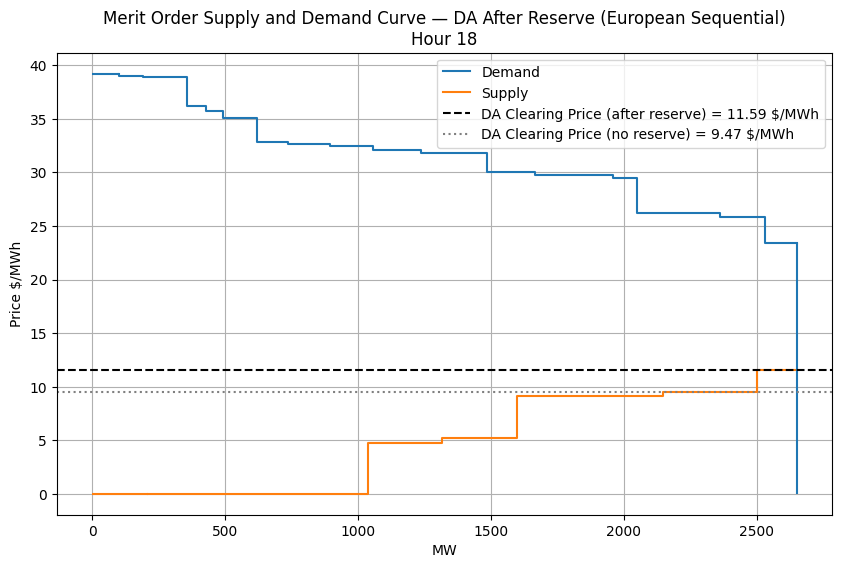

In [8]:
# --- Supply curve — use actual dispatch from model ---
supply_data_DA = [
    (gen_costs.get(g, 0), p_da[g].X)
    for g in VARIABLES
    if p_da[g].X > 1e-3
]
supply_data_sorted_DA = sorted(supply_data_DA, key=lambda x: x[0])
sorted_prices_DA      = [x[0] for x in supply_data_sorted_DA]
sorted_caps_DA        = [x[1] for x in supply_data_sorted_DA]
cumulative_supply_DA  = np.cumsum(sorted_caps_DA)

# --- Demand curve — use actual consumption from model ---
demand_data_DA = [
    (Load_coefficients_DA[l], p_load[l].X)
    for l in LOAD_VARIABLES
    if p_load[l].X > 1e-3
]
demand_data_sorted = sorted(demand_data_DA, key=lambda x: x[0], reverse=True)
demand_sorted_prices = np.array([x[0] for x in demand_data_sorted])
demand_sorted_mw     = np.array([x[1] for x in demand_data_sorted])
cumulative_demand_DA = np.cumsum(demand_sorted_mw)

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.step(cumulative_demand_DA, demand_sorted_prices, label='Demand', color='tab:blue')
plt.step(cumulative_supply_DA, sorted_prices_DA,     label='Supply', color='tab:orange')

# Aesthetic extensions
plt.hlines(y=0,                       xmin=0, xmax=cumulative_supply_DA[0],  color='tab:orange')
plt.hlines(y=demand_sorted_prices[0], xmin=0, xmax=demand_sorted_mw[0],      color='tab:blue')
plt.vlines(x=cumulative_demand_DA[-1],ymin=0, ymax=demand_sorted_prices[-1], color='tab:blue')

plt.axhline(y=lambda_DA_eu, color='black', linestyle='--',
            label=f'DA Clearing Price (after reserve) = {lambda_DA_eu:.2f} $/MWh')
plt.axhline(y=lambda_DA, color='grey', linestyle=':',
            label=f'DA Clearing Price (no reserve) = {lambda_DA:.2f} $/MWh')

plt.xlabel('MW')
plt.ylabel('Price $/MWh')
plt.title('Merit Order Supply and Demand Curve — DA After Reserve (European Sequential)\nHour ' + str(hour))
plt.legend()
plt.grid()
plt.show()

**DA without reserve vs DA with reserve**

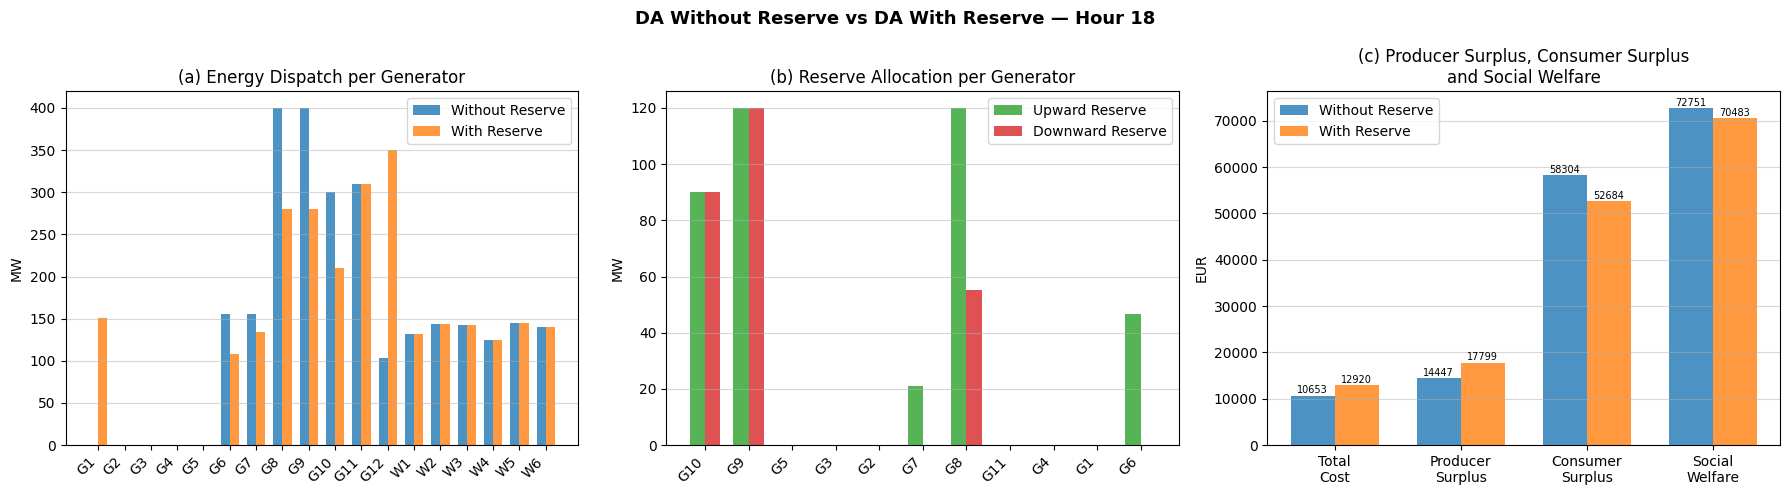


            Energy Clearing Price            
  Scenario                  Price (EUR/MWh)
  ----------------------------------------
  DA Without Reserve                   9.47
  DA With Reserve                     11.59
  Difference                          +2.12


In [9]:
# ── DA WITHOUT RESERVE vs DA WITH RESERVE ─────────────────────────────────────

RESULTS_DIR = os.path.join(os.environ['PYTHONPATH'], 'Results')
width       = 0.35

# --- Prepare data ---
all_gens      = list(p_da.keys())
no_res_disp   = [dispatch_step1.get(g, 0) for g in all_gens]
with_res_disp = [p_da[g].X for g in all_gens]

reserve_gens  = list(RESERVE_SUBSET)
ru_vals       = [reserved_up.get(g, 0)   for g in reserve_gens]
rd_vals       = [reserved_down.get(g, 0) for g in reserve_gens]

welfare_labels = ['Total\nCost', 'Producer\nSurplus', 'Consumer\nSurplus', 'Social\nWelfare']
no_res_vals    = [total_cost_step1, production_surplus_step1, consumer_surplus_step1, social_welfare_step1]
with_res_vals  = [sum(gen_costs.get(g, 0) * p_da[g].X for g in p_da),
                  total_prod_surplus, total_cons_surplus, social_welfare_eu]

# --- Single figure with 3 subplots side by side ---
fig, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'DA Without Reserve vs DA With Reserve — Hour {hour}', fontsize=13, fontweight='bold')

# (a) Energy dispatch
x = np.arange(len(all_gens))
ax_a.bar(x - width/2, no_res_disp,   width, label='Without Reserve', color='tab:blue',   alpha=0.8)
ax_a.bar(x + width/2, with_res_disp, width, label='With Reserve',    color='tab:orange', alpha=0.8)
ax_a.set_xticks(x)
ax_a.set_xticklabels(all_gens, rotation=45, ha='right')
ax_a.set_ylabel('MW')
ax_a.set_title('(a) Energy Dispatch per Generator')
ax_a.legend()
ax_a.grid(axis='y', alpha=0.5)

# (b) Reserve allocation
x3 = np.arange(len(reserve_gens))
ax_b.bar(x3,         ru_vals, width, label='Upward Reserve',   color='tab:green', alpha=0.8)
ax_b.bar(x3 + width, rd_vals, width, label='Downward Reserve', color='tab:red',   alpha=0.8)
ax_b.set_xticks(x3 + width/2)
ax_b.set_xticklabels(reserve_gens, rotation=45, ha='right')
ax_b.set_ylabel('MW')
ax_b.set_title('(b) Reserve Allocation per Generator')
ax_b.legend()
ax_b.grid(axis='y', alpha=0.5)

# (c) Welfare comparison
x6 = np.arange(len(welfare_labels))
ax_c.bar(x6 - width/2, no_res_vals,   width, label='Without Reserve', color='tab:blue',   alpha=0.8)
ax_c.bar(x6 + width/2, with_res_vals, width, label='With Reserve',    color='tab:orange', alpha=0.8)
ax_c.set_xticks(x6)
ax_c.set_xticklabels(welfare_labels)
ax_c.set_ylabel('EUR')
ax_c.set_title('(c) Producer Surplus, Consumer Surplus\nand Social Welfare')
ax_c.legend()
ax_c.grid(axis='y', alpha=0.5)
for i, (nv, wv) in enumerate(zip(no_res_vals, with_res_vals)):
    ax_c.text(i - width/2, nv + 50, f'{nv:.0f}', ha='center', va='bottom', fontsize=7)
    ax_c.text(i + width/2, wv + 50, f'{wv:.0f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig11_DA_reserve_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Table: Energy Clearing Price ---
print(f"\n{'='*45}")
print(f"{'Energy Clearing Price':^45}")
print(f"{'='*45}")
print(f"  {'Scenario':<25} {'Price (EUR/MWh)':>15}")
print(f"  {'-'*40}")
print(f"  {'DA Without Reserve':<25} {lambda_DA:>15.2f}")
print(f"  {'DA With Reserve':<25} {lambda_DA_eu:>15.2f}")
print(f"  {'Difference':<25} {lambda_DA_eu - lambda_DA:>+15.2f}")
print(f"{'='*45}")

***US style: joint reserve + energy market***

In [10]:
# ── US-STYLE JOINT ENERGY + RESERVE MARKET ────────────────────────────────────
#
# In the European sequential market (Step 6a), reserves are cleared FIRST,
# and then the DA energy market is cleared with the remaining capacity.
# This creates inefficiencies: cheap generators may be locked into reserve
# and cannot serve energy, raising the energy price unnecessarily.
#
# In the US-style JOINT market, energy and reserves are cleared SIMULTANEOUSLY
# in a single optimisation. The model decides the optimal split of each
# generator's capacity between energy dispatch and reserve commitment.
#
# Each generator g has three decision variables:
#   p_e[g]  — energy dispatched to the grid [MW]
#   p_ru[g] — upward reserve capacity committed [MW]
#   p_rd[g] — downward reserve capacity committed [MW]
#
# The key physical constraints are:
#   HEADROOM:     p_e[g] + p_ru[g] <= Pmax
#   FOOTROOM:     p_rd[g] <= p_e[g]
#   MAX RESERVE:  p_ru[g] <= 0.3 * Pmax  (same as European market)
#                 p_rd[g] <= 0.3 * Pmax
#
# Opportunity costs (same fractions as European reserve offer prices):
#   Upward reserve:   C_ru[g] = 0.20 * gen_costs[g]
#   Downward reserve: C_rd[g] = 0.15 * gen_costs[g]
#
# Objective = energy cost + upward reserve opportunity cost + downward reserve opportunity cost
# ──────────────────────────────────────────────────────────────────────────────

model_US = gp.Model("Joint_Reserve_Energy_US")
model_US.Params.OutputFlag     = 0
model_US.Params.DualReductions = 0

# --- Opportunity costs (consistent with European reserve offer prices) ---
C_ru = {g: 0.20 * gen_costs[g] for g in conv_names}  # upward reserve cost [$/MWh]
C_rd = {g: 0.15 * gen_costs[g] for g in conv_names}  # downward reserve cost [$/MWh]

# --- Decision variables ---
p_e  = {}   # energy dispatch [MW]
p_ru = {}   # upward reserve capacity [MW]
p_rd = {}   # downward reserve capacity [MW]

for g in conv_names:
    p_e[g]  = model_US.addVar(lb=0, name=f'e_{g}')
    p_ru[g] = model_US.addVar(lb=0, name=f'ru_{g}')
    p_rd[g] = model_US.addVar(lb=0, name=f'rd_{g}')

    # HEADROOM: energy dispatch + upward reserve <= max capacity
    model_US.addConstr(p_e[g] + p_ru[g] <= gen_max_caps[g],       name=f'cap_up_{g}')

    # FOOTROOM: downward reserve <= energy dispatched
    model_US.addConstr(p_rd[g] <= p_e[g],                         name=f'cap_dn_{g}')

    # MAX RESERVE BOUNDS: each generator can offer at most 30% of Pmax for reserve
    # This prevents zero-cost generators from dominating the reserve market
    # and is consistent with the European reserve market offer bounds
    model_US.addConstr(p_ru[g] <= 0.3 * gen_max_caps[g],          name=f'max_ru_{g}')
    model_US.addConstr(p_rd[g] <= 0.3 * gen_max_caps[g],          name=f'max_rd_{g}')

    # Generators outside the reserve subset cannot offer reserves
    if g not in RESERVE_SUBSET:
        model_US.addConstr(p_ru[g] == 0, name=f'no_ru_{g}')
        model_US.addConstr(p_rd[g] == 0, name=f'no_rd_{g}')

# --- Wind variables — energy only ---
# Wind farms have zero marginal cost and do not participate in reserve markets
# Their output is bounded by the hourly available capacity (CF * installed capacity)
p_w = {}
for wi, w in enumerate(wind_names):
    p_w[w] = model_US.addVar(lb=0, ub=Wind_UB[wi], name=f'e_{w}')

# --- Energy balance ---
# Total generation (conventional + wind) must equal total demand
# The dual of this constraint is the energy clearing price lambda_energy_US
model_US.addConstr(
    gp.quicksum(p_e[g] for g in p_e) + gp.quicksum(p_w[w] for w in p_w) == hour_load,
    name="energy_balance"
)

# --- Reserve requirements (15% up, 10% down of total demand) ---
# The duals of these constraints are the reserve clearing prices
model_US.addConstr(gp.quicksum(p_ru[g] for g in p_ru) >= R_up_req,   name="res_up")
model_US.addConstr(gp.quicksum(p_rd[g] for g in p_rd) >= R_down_req, name="res_down")

# --- Objective: minimise energy cost + reserve opportunity costs ---
obj_US = gp.quicksum(
    gen_costs[g] * p_e[g] +
    C_ru[g]      * p_ru[g] +
    C_rd[g]      * p_rd[g]
    for g in p_e
)
model_US.setObjective(obj_US, GRB.MINIMIZE)
model_US.optimize()

# --- Extract clearing prices from dual variables ---
lambda_energy_US = model_US.getConstrByName("energy_balance").Pi
lambda_res_up_US = model_US.getConstrByName("res_up").Pi
lambda_res_dn_US = model_US.getConstrByName("res_down").Pi

# --- Results ---
print(f"US-style joint market results:")
print(f"  Energy clearing price:  {lambda_energy_US:.2f} EUR/MWh")
print(f"  Upward reserve price:   {lambda_res_up_US:.2f} EUR/MWh")
print(f"  Downward reserve price: {lambda_res_dn_US:.2f} EUR/MWh")

print(f"\n  Dispatch:")
for g in p_e:
    if p_e[g].X > 1e-3 or p_ru[g].X > 1e-3 or p_rd[g].X > 1e-3:
        print(f"  {g}: energy={p_e[g].X:.2f} MW  r_up={p_ru[g].X:.2f} MW  r_dn={p_rd[g].X:.2f} MW")
for w in p_w:
    if p_w[w].X > 1e-3:
        print(f"  {w}: energy={p_w[w].X:.2f} MW")

US-style joint market results:
  Energy clearing price:  9.47 EUR/MWh
  Upward reserve price:   3.64 EUR/MWh
  Downward reserve price: 0.79 EUR/MWh

  Dispatch:
  G1: energy=0.00 MW  r_up=45.60 MW  r_dn=0.00 MW
  G2: energy=0.00 MW  r_up=45.60 MW  r_dn=0.00 MW
  G3: energy=0.00 MW  r_up=105.00 MW  r_dn=0.00 MW
  G4: energy=0.00 MW  r_up=15.37 MW  r_dn=0.00 MW
  G6: energy=108.50 MW  r_up=46.50 MW  r_dn=0.00 MW
  G7: energy=108.50 MW  r_up=46.50 MW  r_dn=0.00 MW
  G8: energy=400.00 MW  r_up=0.00 MW  r_dn=55.05 MW
  G9: energy=400.00 MW  r_up=0.00 MW  r_dn=120.00 MW
  G10: energy=300.00 MW  r_up=0.00 MW  r_dn=90.00 MW
  G11: energy=217.00 MW  r_up=93.00 MW  r_dn=0.00 MW
  G12: energy=289.51 MW  r_up=0.00 MW  r_dn=0.00 MW
  W1: energy=131.63 MW
  W2: energy=143.28 MW
  W3: energy=142.54 MW
  W4: energy=124.68 MW
  W5: energy=144.88 MW
  W6: energy=139.97 MW


In [11]:
# --- Generator earnings in US joint market ---
# Each generator is paid:
#   - energy clearing price for energy dispatched
#   - upward reserve clearing price for upward reserve committed
#   - downward reserve clearing price for downward reserve committed

print(f"\nGenerator earnings (US joint market):")
total_prod_surplus_US = 0
for g in p_e:
    earn_energy = (lambda_energy_US - gen_costs[g]) * p_e[g].X
    earn_ru     = lambda_res_up_US * p_ru[g].X
    earn_rd     = lambda_res_dn_US * p_rd[g].X
    total_earn  = earn_energy + earn_ru + earn_rd
    if p_e[g].X > 1e-3 or p_ru[g].X > 1e-3 or p_rd[g].X > 1e-3:
        total_prod_surplus_US += total_earn
        print(f"  {g}: energy={earn_energy:.2f} EUR  r_up={earn_ru:.2f} EUR  r_dn={earn_rd:.2f} EUR  total={total_earn:.2f} EUR")

# --- Total demand payment ---
total_demand_payment_US = lambda_energy_US * hour_load
print(f"\nTotal demand payment: {total_demand_payment_US:.2f} EUR  ({hour_load:.2f} MW x {lambda_energy_US:.2f} EUR/MWh)")

# --- Total generation cost ---
total_gen_cost_US = sum(gen_costs[g] * p_e[g].X for g in p_e)
print(f"Total generation cost: {total_gen_cost_US:.2f} EUR")

# --- Surpluses ---
total_cons_surplus_US = total_demand_payment_US - total_gen_cost_US - total_prod_surplus_US
print(f"\nTotal producer surplus: {total_prod_surplus_US:.2f} EUR")
print(f"Total consumer surplus: {total_cons_surplus_US:.2f} EUR")
print(f"Social welfare (US):    {model_US.ObjVal:.2f} EUR")

# --- Comparison with European sequential ---
print(f"\n--- Comparison: European Sequential vs US Joint ---")
print(f"  Energy price — EU: {lambda_DA_eu:.2f} EUR/MWh   US: {lambda_energy_US:.2f} EUR/MWh   diff: {lambda_energy_US - lambda_DA_eu:+.2f} EUR/MWh")
print(f"  Reserve up  — EU: {lambda_R_up:.2f} EUR/MWh   US: {lambda_res_up_US:.2f} EUR/MWh   diff: {lambda_res_up_US - lambda_R_up:+.2f} EUR/MWh")
print(f"  Reserve dn  — EU: {lambda_R_down:.2f} EUR/MWh   US: {lambda_res_dn_US:.2f} EUR/MWh   diff: {lambda_res_dn_US - lambda_R_down:+.2f} EUR/MWh")


Generator earnings (US joint market):
  G1: energy=-0.00 EUR  r_up=166.08 EUR  r_dn=0.00 EUR  total=166.08 EUR
  G2: energy=-0.00 EUR  r_up=166.08 EUR  r_dn=0.00 EUR  total=166.08 EUR
  G3: energy=-0.00 EUR  r_up=382.41 EUR  r_dn=0.00 EUR  total=382.41 EUR
  G4: energy=-0.00 EUR  r_up=56.00 EUR  r_dn=0.00 EUR  total=56.00 EUR
  G6: energy=34.72 EUR  r_up=169.35 EUR  r_dn=0.00 EUR  total=204.07 EUR
  G7: energy=34.72 EUR  r_up=169.35 EUR  r_dn=0.00 EUR  total=204.07 EUR
  G8: energy=1692.00 EUR  r_up=0.00 EUR  r_dn=43.27 EUR  total=1735.27 EUR
  G9: energy=1884.00 EUR  r_up=0.00 EUR  r_dn=94.32 EUR  total=1978.32 EUR
  G10: energy=2841.00 EUR  r_up=0.00 EUR  r_dn=70.74 EUR  total=2911.74 EUR
  G11: energy=69.44 EUR  r_up=338.71 EUR  r_dn=0.00 EUR  total=408.15 EUR
  G12: energy=0.00 EUR  r_up=0.00 EUR  r_dn=0.00 EUR  total=0.00 EUR

Total demand payment: 25100.24 EUR  (2650.50 MW x 9.47 EUR/MWh)
Total generation cost: 10712.76 EUR

Total producer surplus: 8212.18 EUR
Total consumer sur

***European sequential vs US joint***

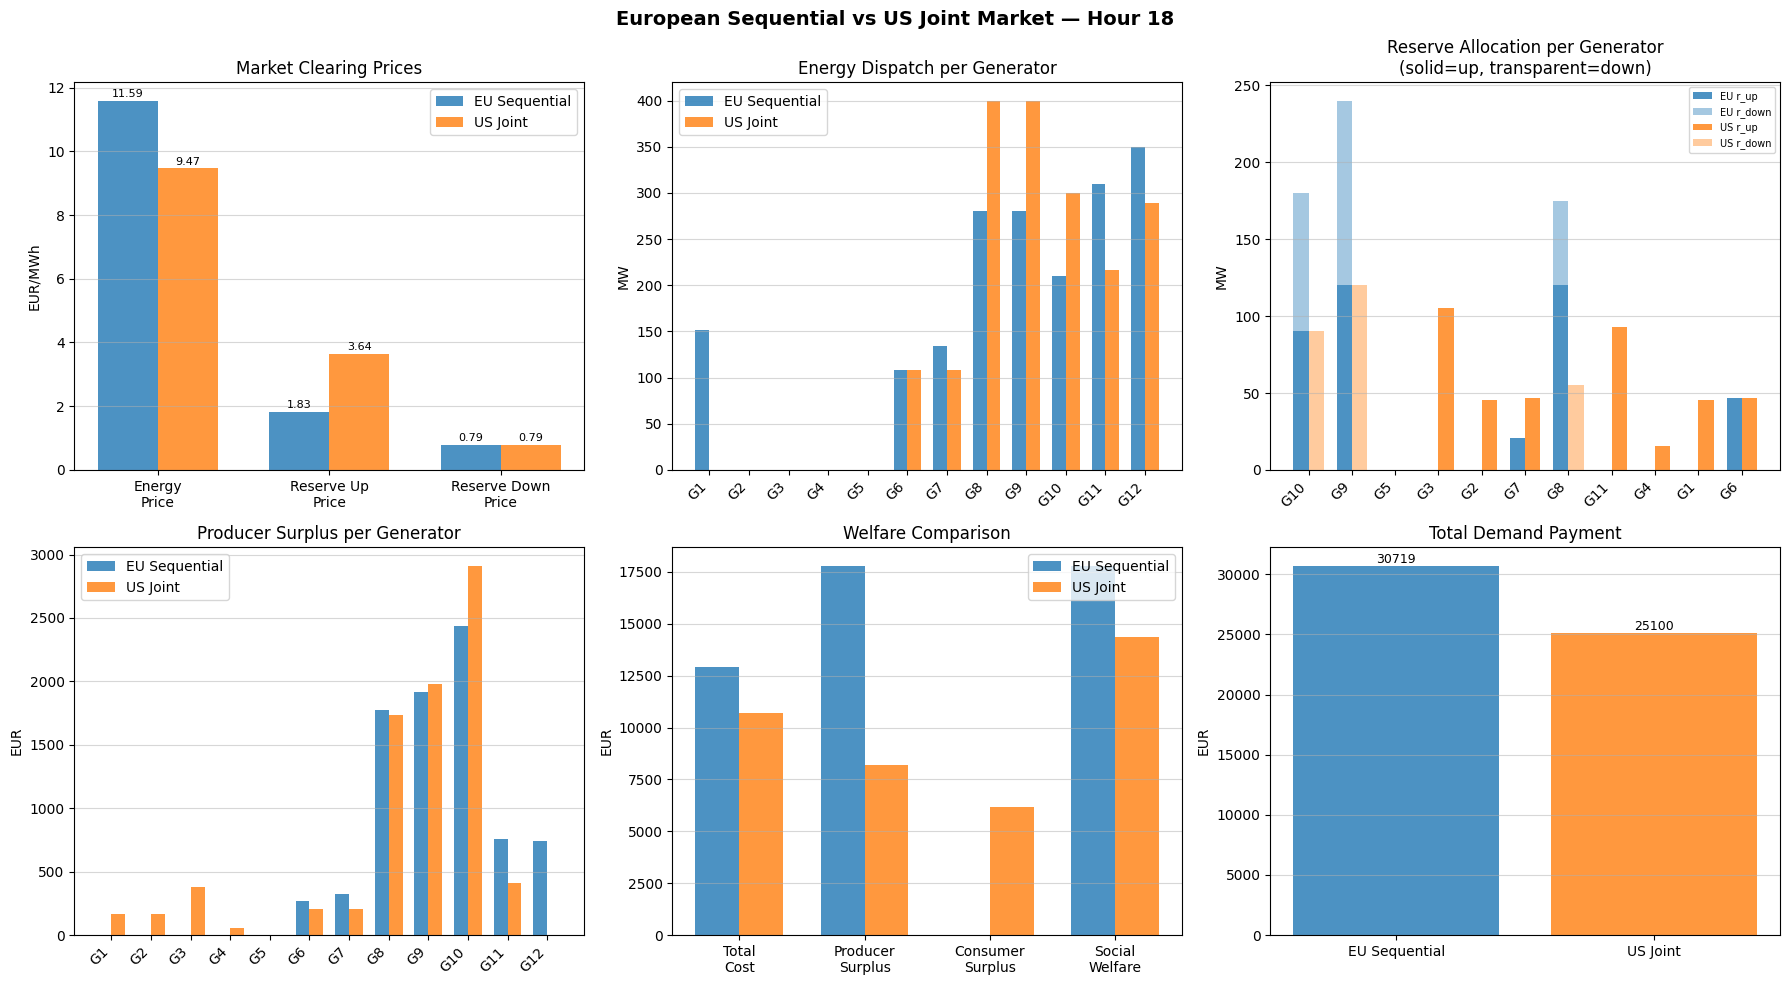

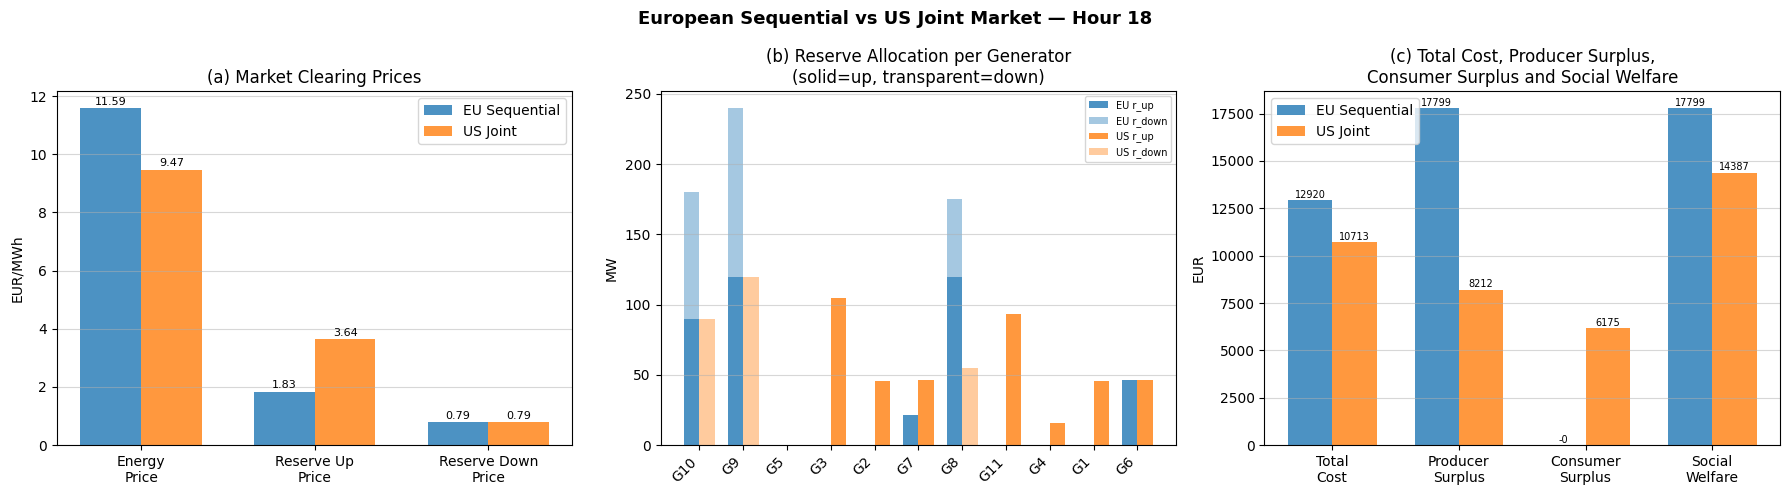

In [12]:
# ── EUROPEAN SEQUENTIAL vs US JOINT MARKET ────────────────────────────────────

RESULTS_DIR = os.path.join(os.environ['PYTHONPATH'], 'Results')
width       = 0.35

# --- Prepare data ---
gen_list     = list(p_e.keys())
reserve_gens = list(RESERVE_SUBSET)

eu_dispatch = [p_da[g].X if g in p_da else 0 for g in gen_list]
us_dispatch = [p_e[g].X                       for g in gen_list]

eu_ru = [reserved_up.get(g, 0)   for g in reserve_gens]
eu_rd = [reserved_down.get(g, 0) for g in reserve_gens]
us_ru = [p_ru[g].X               for g in reserve_gens]
us_rd = [p_rd[g].X               for g in reserve_gens]

eu_prod = sum((lambda_DA_eu     - gen_costs.get(g, 0)) * p_da[g].X for g in p_da)
us_prod = sum((lambda_energy_US - gen_costs.get(g, 0)) * p_e[g].X +
               lambda_res_up_US * p_ru[g].X +
               lambda_res_dn_US * p_rd[g].X for g in p_e)
eu_cons = lambda_DA_eu     * hour_load - sum(gen_costs.get(g, 0) * p_da[g].X for g in p_da) - eu_prod
us_cons = lambda_energy_US * hour_load - sum(gen_costs.get(g, 0) * p_e[g].X  for g in p_e)  - us_prod

eu_prices = [lambda_DA_eu,     lambda_R_up,      lambda_R_down]
us_prices = [lambda_energy_US, lambda_res_up_US, lambda_res_dn_US]

welfare_labels_c = ['Total\nCost', 'Producer\nSurplus', 'Consumer\nSurplus', 'Social\nWelfare']
eu_welfare_c     = [sum(gen_costs.get(g, 0) * p_da[g].X for g in p_da),
                    eu_prod, eu_cons, eu_prod + eu_cons]
us_welfare_c     = [sum(gen_costs.get(g, 0) * p_e[g].X for g in p_e),
                    us_prod, us_cons, us_prod + us_cons]

# =============================================================================
# DASHBOARD — shown in notebook only, not saved
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'European Sequential vs US Joint Market — Hour {hour}', fontsize=14, fontweight='bold')

# 1. Clearing prices
ax = axes[0, 0]
x = np.arange(3)
ax.bar(x - width/2, eu_prices, width, label='EU Sequential', color='tab:blue',   alpha=0.8)
ax.bar(x + width/2, us_prices, width, label='US Joint',      color='tab:orange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['Energy\nPrice', 'Reserve Up\nPrice', 'Reserve Down\nPrice'])
ax.set_ylabel('EUR/MWh')
ax.set_title('Market Clearing Prices')
ax.legend()
ax.grid(axis='y', alpha=0.5)
for i, (eu, us) in enumerate(zip(eu_prices, us_prices)):
    ax.text(i - width/2, eu + 0.05, f'{eu:.2f}', ha='center', va='bottom', fontsize=8)
    ax.text(i + width/2, us + 0.05, f'{us:.2f}', ha='center', va='bottom', fontsize=8)

# 2. Energy dispatch
ax = axes[0, 1]
x2 = np.arange(len(gen_list))
ax.bar(x2 - width/2, eu_dispatch, width, label='EU Sequential', color='tab:blue',   alpha=0.8)
ax.bar(x2 + width/2, us_dispatch, width, label='US Joint',      color='tab:orange', alpha=0.8)
ax.set_xticks(x2)
ax.set_xticklabels(gen_list, rotation=45, ha='right')
ax.set_ylabel('MW')
ax.set_title('Energy Dispatch per Generator')
ax.legend()
ax.grid(axis='y', alpha=0.5)

# 3. Reserve allocation
ax = axes[0, 2]
x3 = np.arange(len(reserve_gens))
ax.bar(x3 - width/2, eu_ru, width, label='EU r_up',   color='tab:blue',   alpha=0.8)
ax.bar(x3 - width/2, eu_rd, width, label='EU r_down', color='tab:blue',   alpha=0.4, bottom=eu_ru)
ax.bar(x3 + width/2, us_ru, width, label='US r_up',   color='tab:orange', alpha=0.8)
ax.bar(x3 + width/2, us_rd, width, label='US r_down', color='tab:orange', alpha=0.4, bottom=us_ru)
ax.set_xticks(x3)
ax.set_xticklabels(reserve_gens, rotation=45, ha='right')
ax.set_ylabel('MW')
ax.set_title('Reserve Allocation per Generator\n(solid=up, transparent=down)')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.5)

# 4. Producer surplus
ax = axes[1, 0]
eu_surplus = [(lambda_DA_eu     - gen_costs.get(g, 0)) * p_da[g].X if g in p_da else 0 for g in gen_list]
us_surplus = [(lambda_energy_US - gen_costs.get(g, 0)) * p_e[g].X +
               lambda_res_up_US * p_ru[g].X +
               lambda_res_dn_US * p_rd[g].X for g in gen_list]
x4 = np.arange(len(gen_list))
ax.bar(x4 - width/2, eu_surplus, width, label='EU Sequential', color='tab:blue',   alpha=0.8)
ax.bar(x4 + width/2, us_surplus, width, label='US Joint',      color='tab:orange', alpha=0.8)
ax.set_xticks(x4)
ax.set_xticklabels(gen_list, rotation=45, ha='right')
ax.set_ylabel('EUR')
ax.set_title('Producer Surplus per Generator')
ax.legend()
ax.grid(axis='y', alpha=0.5)

# 5. Welfare comparison
ax = axes[1, 1]
x5 = np.arange(len(welfare_labels_c))
ax.bar(x5 - width/2, eu_welfare_c, width, label='EU Sequential', color='tab:blue',   alpha=0.8)
ax.bar(x5 + width/2, us_welfare_c, width, label='US Joint',      color='tab:orange', alpha=0.8)
ax.set_xticks(x5)
ax.set_xticklabels(welfare_labels_c)
ax.set_ylabel('EUR')
ax.set_title('Welfare Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.5)

# 6. Total demand payment
ax = axes[1, 2]
payments = [lambda_DA_eu * hour_load, lambda_energy_US * hour_load]
bars = ax.bar(['EU Sequential', 'US Joint'], payments, color=['tab:blue', 'tab:orange'], alpha=0.8)
ax.set_ylabel('EUR')
ax.set_title('Total Demand Payment')
ax.grid(axis='y', alpha=0.5)
for bar, val in zip(bars, payments):
    ax.text(bar.get_x() + bar.get_width()/2, val + 10, f'{val:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()  # dashboard shown in notebook only — NOT saved

# =============================================================================
# SAVED FIGURE — report quality, 3 subplots side by side
# =============================================================================
fig12, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(18, 5))
fig12.suptitle(f'European Sequential vs US Joint Market — Hour {hour}', fontsize=13, fontweight='bold')

# (a) Market clearing prices
x = np.arange(3)
ax_a.bar(x - width/2, eu_prices, width, label='EU Sequential', color='tab:blue',   alpha=0.8)
ax_a.bar(x + width/2, us_prices, width, label='US Joint',      color='tab:orange', alpha=0.8)
ax_a.set_xticks(x)
ax_a.set_xticklabels(['Energy\nPrice', 'Reserve Up\nPrice', 'Reserve Down\nPrice'])
ax_a.set_ylabel('EUR/MWh')
ax_a.set_title('(a) Market Clearing Prices')
ax_a.legend()
ax_a.grid(axis='y', alpha=0.5)
for i, (eu, us) in enumerate(zip(eu_prices, us_prices)):
    ax_a.text(i - width/2, eu + 0.05, f'{eu:.2f}', ha='center', va='bottom', fontsize=8)
    ax_a.text(i + width/2, us + 0.05, f'{us:.2f}', ha='center', va='bottom', fontsize=8)

# (b) Reserve allocation
x3 = np.arange(len(reserve_gens))
ax_b.bar(x3 - width/2, eu_ru, width, label='EU r_up',   color='tab:blue',   alpha=0.8)
ax_b.bar(x3 - width/2, eu_rd, width, label='EU r_down', color='tab:blue',   alpha=0.4, bottom=eu_ru)
ax_b.bar(x3 + width/2, us_ru, width, label='US r_up',   color='tab:orange', alpha=0.8)
ax_b.bar(x3 + width/2, us_rd, width, label='US r_down', color='tab:orange', alpha=0.4, bottom=us_ru)
ax_b.set_xticks(x3)
ax_b.set_xticklabels(reserve_gens, rotation=45, ha='right')
ax_b.set_ylabel('MW')
ax_b.set_title('(b) Reserve Allocation per Generator\n(solid=up, transparent=down)')
ax_b.legend(fontsize=7)
ax_b.grid(axis='y', alpha=0.5)

# (c) Total cost, producer surplus, consumer surplus and social welfare
x_c = np.arange(len(welfare_labels_c))
ax_c.bar(x_c - width/2, eu_welfare_c, width, label='EU Sequential', color='tab:blue',   alpha=0.8)
ax_c.bar(x_c + width/2, us_welfare_c, width, label='US Joint',      color='tab:orange', alpha=0.8)
ax_c.set_xticks(x_c)
ax_c.set_xticklabels(welfare_labels_c)
ax_c.set_ylabel('EUR')
ax_c.set_title('(c) Total Cost, Producer Surplus,\nConsumer Surplus and Social Welfare')
ax_c.legend()
ax_c.grid(axis='y', alpha=0.5)
for i, (eu, us) in enumerate(zip(eu_welfare_c, us_welfare_c)):
    ax_c.text(i - width/2, eu + 10, f'{eu:.0f}', ha='center', va='bottom', fontsize=7)
    ax_c.text(i + width/2, us + 10, f'{us:.0f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig12_EU_vs_US_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()